Christine Reisa P. Mosqueda

BSIT - 4R8

data-60 Diabetes Dataset (UCI Repository)

# Extract

Import all necessary libraries.

In [82]:
import pandas as pd
import numpy as np
from datetime import timedelta

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Import the dataset, create a dataframe for it, and create columns for each feature. Also, view its shape and the first 10 rows to validate the dataframe's content.

In [83]:
df = pd.read_csv("../datasets/data-60-diabetes", sep="\t", header=None)
df.columns = ["date", "time", "code", "value"]

print("Raw dataset shape:", df.shape)

print("printing the first 10 rows:")
df.head(10)

Raw dataset shape: (300, 4)
printing the first 10 rows:


,date,time,code,value
0,04-15-1991,13:08,33,5
1,04-15-1991,17:17,62,41
2,04-15-1991,18:23,33,6
3,04-15-1991,18:24,35,3
4,04-15-1991,21:16,64,119
5,04-15-1991,21:17,35,7
6,04-16-1991,06:05,58,101
7,04-16-1991,06:07,33,4
8,04-16-1991,06:07,35,10
9,04-16-1991,11:03,60,62


Check if there are missing values or NaNs fo each column

In [84]:
df.isna().sum()

date     0
time     0
code     0
value    0
dtype: int64

# Transform

We will need to map out the codes since these codes tell us specific events of when these patient records were taken. The glucose codes pertains to glucose measurements, while the feature codes pertains to the events like insulin, meals, exercise, and symptoms that may influence glucose. We will also need to categorize glucose readings to classify values (low, normal, high)

In [85]:
# Combine date and time into a single datetime column
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])

# codes mapping
glucose_codes = [48, 57, 58, 59, 60, 61, 62, 63, 64]
feature_codes = [33, 34, 35, 65, 66, 67, 68, 69, 70, 71]

# Separate glucose and events
glucose_df = df[df["code"].isin(glucose_codes)].copy()
glucose_df.rename(columns={"value": "glucose"}, inplace=True)

events_df = df[df["code"].isin(feature_codes)].copy()

# Categorize glucose readings (classification labels)
def categorize_glucose(value):
    if value < 70:
        return 0  # Low
    elif value <= 180:
        return 1  # Normal
    else:
        return 2  # High


glucose_df["glucose_class"] = glucose_df["glucose"].apply(categorize_glucose)

# Sort glucose_df for rolling calculations
glucose_df = glucose_df.sort_values("datetime")
glucose_df.set_index("datetime", inplace=True)

# Rolling glucose statistics (past 6 hours)
glucose_df["glucose_rolling_mean_6h"] = glucose_df["glucose"].rolling('6h').mean()
glucose_df["glucose_rolling_max_6h"] = glucose_df["glucose"].rolling('6h').max()
glucose_df["glucose_rolling_min_6h"] = glucose_df["glucose"].rolling('6h').min()

# Reset index if you want datetime back as a column
glucose_df.reset_index(inplace=True)

We will need to feature engineer the raw data and transform it into meaningful features that makes sense for model to learn from. For both models, we want to predict whether the glucose at 12:00 will be low, normal, or high. This is especially helpful because the time stamps are already provided.

In [86]:
# Feature engineering: window events + cumulative counts
feature_rows = []

for _, row in glucose_df.iterrows():
    current_time = row["datetime"]
    start_time = current_time - timedelta(hours=12)  # expand window to 12h
    
    window_events = events_df[
        (events_df["datetime"] >= start_time) &
        (events_df["datetime"] < current_time)
    ]
    
    features = {
        "datetime": current_time,
        "glucose_class": row["glucose_class"],
        "glucose_rolling_mean_6h": row["glucose_rolling_mean_6h"],
        "glucose_rolling_max_6h": row["glucose_rolling_max_6h"],
        "glucose_rolling_min_6h": row["glucose_rolling_min_6h"],
        "insulin_dose_6h": window_events[window_events["code"].isin([33,34,35])]["value"].sum(),
        "meals_6h": window_events[window_events["code"].isin([66,67,68])].shape[0],
        "exercise_6h": window_events[window_events["code"].isin([69,70,71])].shape[0],
        "symptoms_6h": window_events[window_events["code"] == 65].shape[0],
        # cumulative counts over 12 hours
        "total_meals_12h": events_df[(events_df["datetime"] >= current_time - timedelta(hours=12)) &
                                     (events_df["code"].isin([66,67,68]))].shape[0],
        "total_exercise_12h": events_df[(events_df["datetime"] >= current_time - timedelta(hours=12)) &
                                        (events_df["code"].isin([69,70,71]))].shape[0],
        "total_symptoms_12h": events_df[(events_df["datetime"] >= current_time - timedelta(hours=12)) &
                                        (events_df["code"] == 65)].shape[0]
    }
    
    feature_rows.append(features)

ml_df = pd.DataFrame(feature_rows)
print("First 10 rows of ML dataset:")
print(ml_df.head(10))

# Drop rows with NaNs from rolling calculations
ml_df = ml_df.dropna()

First 10 rows of ML dataset:
             datetime  glucose_class  glucose_rolling_mean_6h  \
0 1991-04-15 17:17:00              0                41.000000   
1 1991-04-15 21:16:00              1                80.000000   
2 1991-04-16 06:05:00              1               101.000000   
3 1991-04-16 11:03:00              0                81.500000   
4 1991-04-16 11:46:00              1                81.666667   
5 1991-04-16 18:28:00              1               168.000000   
6 1991-04-16 20:21:00              1               128.500000   
7 1991-04-17 05:46:00              1               132.000000   
8 1991-04-17 11:43:00              0                83.500000   
9 1991-04-17 13:03:00              2               133.000000   

   glucose_rolling_max_6h  glucose_rolling_min_6h  insulin_dose_6h  meals_6h  \
0                    41.0                    41.0                5         0   
1                   119.0                    41.0               14         0   
2              

# Load / Modeling

We will now convert the feature-engineered dataframe into its features and labels, as well as split it into training sets and test sets.

For training set will be 80% of the df, while 20% is for test set.

In [87]:
# Features and labels
X = ml_df[[
    "glucose_rolling_mean_6h", "glucose_rolling_max_6h", "glucose_rolling_min_6h",
    "insulin_dose_6h", "meals_6h", "exercise_6h", "symptoms_6h",
    "total_meals_12h", "total_exercise_12h", "total_symptoms_12h"
]]
y = ml_df["glucose_class"]


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Then, we will be creating the pipelines for both logistic regression and decision tree models. Pipelines are optional but here, I used it because it makes the code cleaner and we can also reuse them later on if needed.

In [88]:
# Logistic Regression pipeline
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=1000))
])

# Decision Tree pipeline
dt_pipeline = Pipeline([
    ("dt", DecisionTreeClassifier(random_state=42))
])

After creating pipelines, we can now train both models using the pipelines and predict the results.

In [89]:
# Train both models
log_reg_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)

# Predictions
y_pred_log = log_reg_pipeline.predict(X_test)
y_pred_dt = dt_pipeline.predict(X_test)

Here, we will now print out the evaluation results for both models.

In [90]:
# Evaluation
print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print("=== Decision Tree Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

=== Logistic Regression Results ===
Accuracy: 0.8260869565217391
[[ 3  3  0]
 [ 0 10  1]
 [ 0  0  6]]
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.77      0.91      0.83        11
           2       0.86      1.00      0.92         6

    accuracy                           0.83        23
   macro avg       0.88      0.80      0.81        23
weighted avg       0.85      0.83      0.81        23

=== Decision Tree Results ===
Accuracy: 0.8695652173913043
[[5 1 0]
 [1 9 1]
 [0 0 6]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.90      0.82      0.86        11
           2       0.86      1.00      0.92         6

    accuracy                           0.87        23
   macro avg       0.86      0.88      0.87        23
weighted avg       0.87      0.87      0.87        23



# Visualize Results

This is a centralized dashboard to visualize all results for both Logistic Regression and Decision Tree. The following visualizations tells us what these results are showing:

- **Confusion Matrices:** Shows how many samples were correctly or incorrectly classified for each class.
- **ROC Curves (One-vs-Rest):** How well the model distinguishes each class from the others.
- **Feature Importance (Decision Tree only):** Which features the Decision Tree relies on most for making predictions. Higher importance → stronger influence on the predicted class.

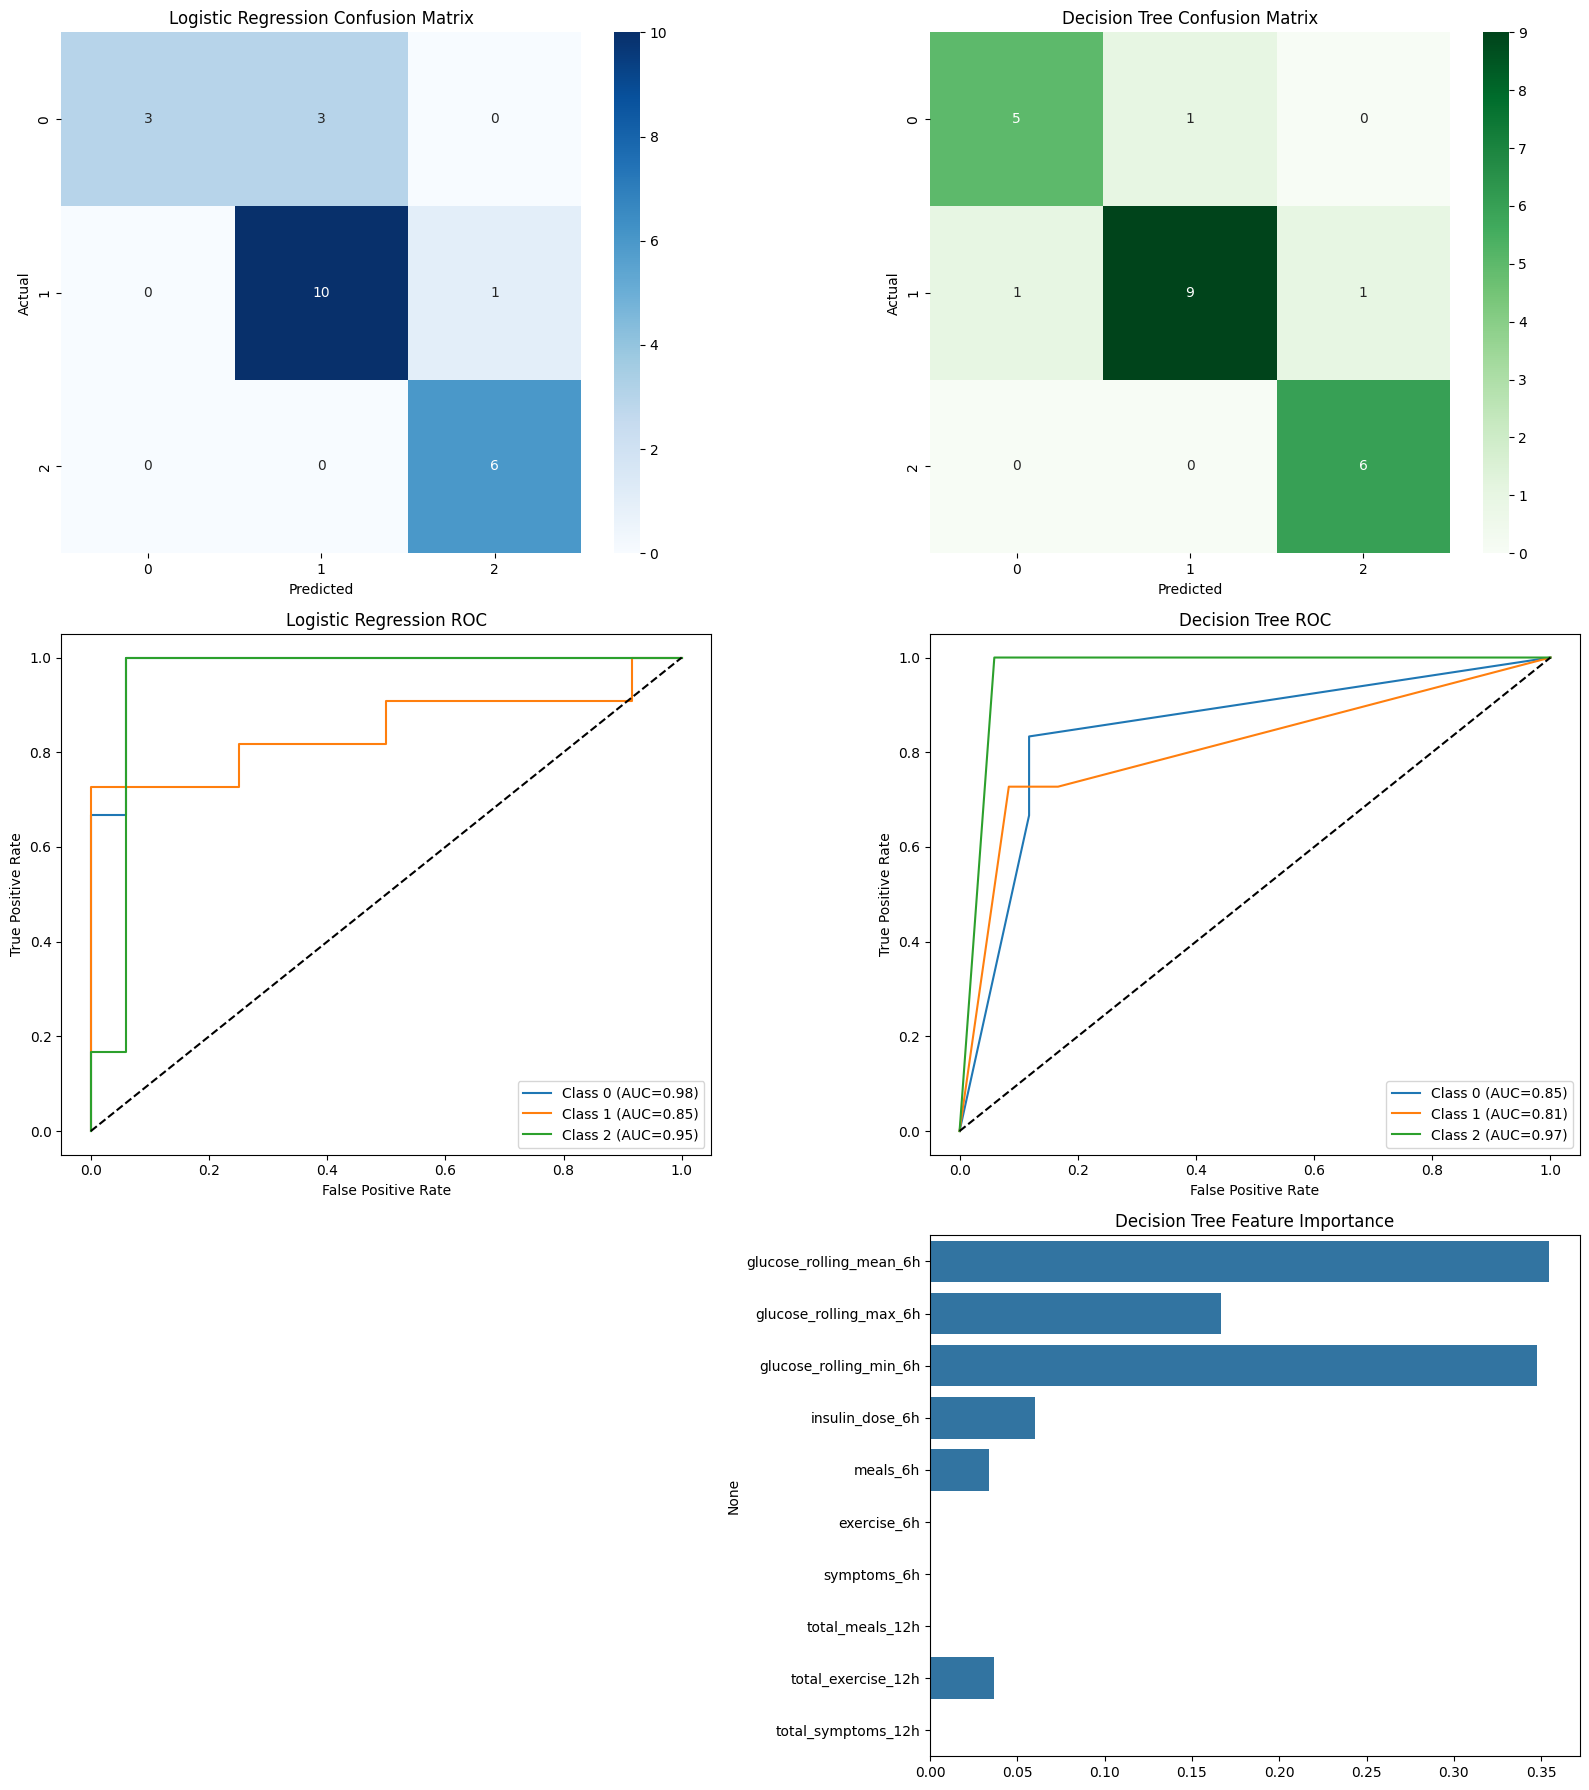

In [91]:
# Binarize labels for ROC
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = y_test_bin.shape[1]

# Models wrapped in OvR for multi-class ROC
logreg_ovr = OneVsRestClassifier(log_reg_pipeline)
dt_ovr = OneVsRestClassifier(dt_pipeline)

y_score_logreg = logreg_ovr.fit(X_train, y_train).predict_proba(X_test)
y_score_dt = dt_ovr.fit(X_train, y_train).predict_proba(X_test)

y_pred_logreg = log_reg_pipeline.predict(X_test)
y_pred_dt = dt_pipeline.predict(X_test)

# Set up dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# =====================
# Confusion Matrices
# =====================
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues", ax=axes[0,0])
axes[0,0].set_title("Logistic Regression Confusion Matrix")
axes[0,0].set_xlabel("Predicted")
axes[0,0].set_ylabel("Actual")

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens", ax=axes[0,1])
axes[0,1].set_title("Decision Tree Confusion Matrix")
axes[0,1].set_xlabel("Predicted")
axes[0,1].set_ylabel("Actual")

# =====================
# ROC Curves
# =====================
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_logreg[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1,0].plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_dt[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1,1].plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')

axes[1,0].plot([0,1], [0,1], 'k--')
axes[1,0].set_title("Logistic Regression ROC")
axes[1,0].set_xlabel("False Positive Rate")
axes[1,0].set_ylabel("True Positive Rate")
axes[1,0].legend(loc='lower right')

axes[1,1].plot([0,1], [0,1], 'k--')
axes[1,1].set_title("Decision Tree ROC")
axes[1,1].set_xlabel("False Positive Rate")
axes[1,1].set_ylabel("True Positive Rate")
axes[1,1].legend(loc='lower right')

# =====================
# Feature Importance (Decision Tree)
# =====================
importances = dt_pipeline.named_steps['dt'].feature_importances_
features = X_train.columns

sns.barplot(x=importances, y=features, ax=axes[2,1])
axes[2,1].set_title("Decision Tree Feature Importance")

axes[2,0].axis('off')  # Empty cell

plt.tight_layout()
plt.show()

# Overall Conclusion from Visualizations

1. Decision Tree is better suited for this dataset than Logistic Regression, achieving higher accuracy and more balanced recall across classes.
2. Certain features have strong predictive power, particularly rolling glucose statistics and recent events (like symptoms).
3. Model performance is acceptable but not perfect, especially for classes with fewer samples; collecting more data could help.
4. Feature engineering matters: Rolling averages and event counts significantly improve prediction capability.